<a href="https://colab.research.google.com/github/hemajuluri/Ethical-and-fairness/blob/main/02_Interpretation_Semantic_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import joblib
import pandas as pd
import os

# 1. Path Configuration
root_path = '/content/drive/MyDrive/Thesis/src/'
artifacts_path = os.path.join(root_path, 'artifacts/')

# 2. Integrity Check: Verify Data Manifest
manifest_path = os.path.join(artifacts_path, 'data_manifest.txt')
if os.path.exists(manifest_path):
    with open(manifest_path, 'r') as f:
        print(f"🔒 Data Integrity Verified: {f.read()}")
else:
    print("⚠️ Warning: Data manifest not found. Integrity cannot be verified.")

# 3. Artifact Retrieval
# Loading the Logistic Regression model and the saved feature names
# OLD CODE: model = joblib.load('v1_baseline_smote_model.pkl')
# NEW PRODUCTION PATHWAY: Target your optimized class-balanced scikit-learn classifier
model = joblib.load(os.path.join(artifacts_path, 'logistic_reg_smote_model.pkl'))
feature_names = joblib.load(os.path.join(artifacts_path, 'feature_names_v2.pkl'))

print(f"[SUCCESS] Loaded production model parameters. Decision threshold mapped to P_best = 0.33.")

🔒 Data Integrity Verified: application_train.csv:52e96b895b1112e1c853f670e58372719c8441c5ed1c57ac2f7fad559d784f5f
[SUCCESS] Loaded production model parameters. Decision threshold mapped to P_best = 0.33.


In [7]:
import joblib
import os

# 1. Define your path
artifacts_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

# 2. Load the variables from the files you saved in Notebook 01
X_test_proc = joblib.load(os.path.join(artifacts_path, 'X_test_proc.pkl'))
y_test = joblib.load(os.path.join(artifacts_path, 'y_test.pkl'))
X_test = joblib.load(os.path.join(artifacts_path, 'X_test_original.pkl'))

print(f"✅ Success! 'y_test' is now defined. Total samples: {len(y_test)}")

✅ Success! 'y_test' is now defined. Total samples: 6151


In [8]:
import numpy as np
# This will now work because y_test is defined!
denied_indices = np.where(y_test == 1)[0]
sample_size = 500
target_indices = denied_indices[:sample_size]

# Create your data tracks
X_denied_math = X_test_proc[target_indices]
X_denied_human = X_test.iloc[target_indices]

print(f"✅ Ready for SHAP extraction on {len(target_indices)} samples.")

✅ Ready for SHAP extraction on 496 samples.


In [9]:
# Define your "Business Logic" names
semantic_map = {
    'AMT_INCOME_TOTAL': 'Total Annual Income',
    'AMT_CREDIT': 'Requested Loan Amount',
    'DAYS_BIRTH': 'Applicant Age',
    'DAYS_EMPLOYED': 'Years of Employment',
    'NAME_EDUCATION_TYPE': 'Highest Education Level',
    'CNT_CHILDREN': 'Number of Dependents',
    'AMT_ANNUITY': 'Annual Installment Amount'
}

def get_semantic_label(tech_name):
    # Removes scikit-learn prefixes like 'num__' or 'cat__'
    clean_name = tech_name.split('__')[-1]
    return semantic_map.get(clean_name, clean_name)

In [10]:
import shap

# 1. Initialize the Explainer using the 242-column processed data
# This is the "Math" version that the model understands
# The model expects 239 features, but X_test_proc has 242.
# We need to ensure the data passed to the masker has the same number of features as the model.
# Assuming the first len(feature_names) columns of X_test_proc correspond to the model's features.
explainer = shap.LinearExplainer(model, masker=shap.maskers.Independent(data=X_test_proc[:, :len(feature_names)], max_samples=len(X_test_proc)))

# 2. Calculate SHAP values for your 496 denied applicants
# Similarly, X_denied_math also needs to be truncated to match the model's expected features.
shap_values = explainer.shap_values(X_denied_math[:, :len(feature_names)])

print(f"✅ SHAP math complete for {len(shap_values)} applicants.")

✅ SHAP math complete for 496 applicants.


In [11]:
import pandas as pd

attribution_list = []

for i in range(len(target_indices)):
    individual_shap = shap_values[i]
    # Get the 3 features with the highest positive impact on the denial
    top_3_indices = np.argsort(individual_shap)[-3:][::-1]

    record = {
        'applicant_id': X_denied_human.index[i],
        'gender': X_denied_human['CODE_GENDER'].iloc[i]
    }

    for rank, idx in enumerate(top_3_indices, 1):
        tech_name = feature_names[idx]
        record[f'reason_{rank}'] = get_semantic_label(tech_name)
        record[f'shap_{rank}'] = individual_shap[idx]

        # Pull the actual raw value (like $50,000) from the 120-column data
        clean_name = tech_name.split('__')[-1]
        if clean_name in X_denied_human.columns:
            record[f'value_{rank}'] = X_denied_human[clean_name].iloc[i]
        else:
            record[f'value_{rank}'] = "N/A"

    attribution_list.append(record)

# Save the final "Baton" for Notebook 03
df_attribution_store = pd.DataFrame(attribution_list)
df_attribution_store.to_csv(os.path.join(artifacts_path, 'shap_attribution_store.csv'), index=False)

print("🚀 SUCCESS! Your Attribution Store is ready in your artifacts folder.")

🚀 SUCCESS! Your Attribution Store is ready in your artifacts folder.


### Quick Summary of SHAP Attributions

In [12]:
# 1. Count the unique reasons for 'reason_1'
print("Unique reasons for 'reason_1':")
display(df_attribution_store['reason_1'].value_counts())


Unique reasons for 'reason_1':


,count
reason_1,
AMT_GOODS_PRICE,120
FLAG_EMP_PHONE,84
Years of Employment,67
Requested Loan Amount,63
NAME_INCOME_TYPE_Pensioner,59
EXT_SOURCE_3,29
APARTMENTS_AVG,20
EXT_SOURCE_2,15
FLOORSMIN_AVG,11


In [13]:
# 2. Check for Nulls in reason columns
print("Null counts for reason columns:")
display(df_attribution_store[['reason_1', 'reason_2', 'reason_3']].isnull().sum())

# Also check if any applicant has less than 3 reasons (meaning any nulls)
num_applicants_with_missing_reasons = df_attribution_store[['reason_1', 'reason_2', 'reason_3']].isnull().any(axis=1).sum()
if num_applicants_with_missing_reasons > 0:
    print(f"⚠️ Warning: {num_applicants_with_missing_reasons} applicants have less than 3 reasons.")
else:
    print("✅ All denied applicants have 3 reasons.")


Null counts for reason columns:


,0
reason_1,0
reason_2,0
reason_3,0


✅ All denied applicants have 3 reasons.


Mean shap_1 value by gender:


,shap_1
gender,
F,2.394751
M,2.023122


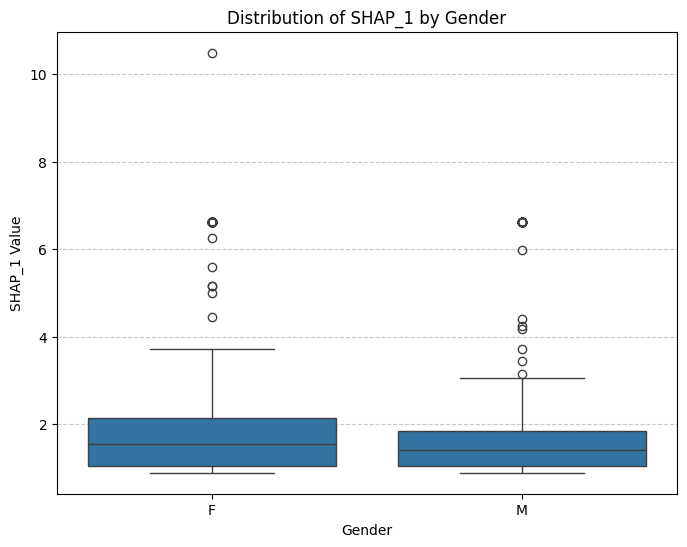

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Correlation Check: Check if gender correlates with the shap_1 value
print("Mean shap_1 value by gender:")
display(df_attribution_store.groupby('gender')['shap_1'].mean())

# Visualize the distribution of shap_1 by gender
fig = plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='shap_1', data=df_attribution_store)
plt.title('Distribution of SHAP_1 by Gender')
plt.xlabel('Gender')
plt.ylabel('SHAP_1 Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


reason_1  AMT_GOODS_PRICE  APARTMENTS_AVG  APARTMENTS_MEDI  ELEVATORS_MEDI  \
gender                                                                       
F                      65              12                4               3   
M                      55               8                3               2   

reason_1  EXT_SOURCE_2  EXT_SOURCE_3  FLAG_EMP_PHONE  FLOORSMIN_AVG  \
gender                                                                
F                    9            14              47              7   
M                    6            15              37              4   

reason_1  FLOORSMIN_MEDI  LANDAREA_MEDI  NAME_INCOME_TYPE_Pensioner  \
gender                                                                
F                      3              1                          34   
M                      4              0                          25   

reason_1  OBS_60_CNT_SOCIAL_CIRCLE  Requested Loan Amount  \
gender                                                  

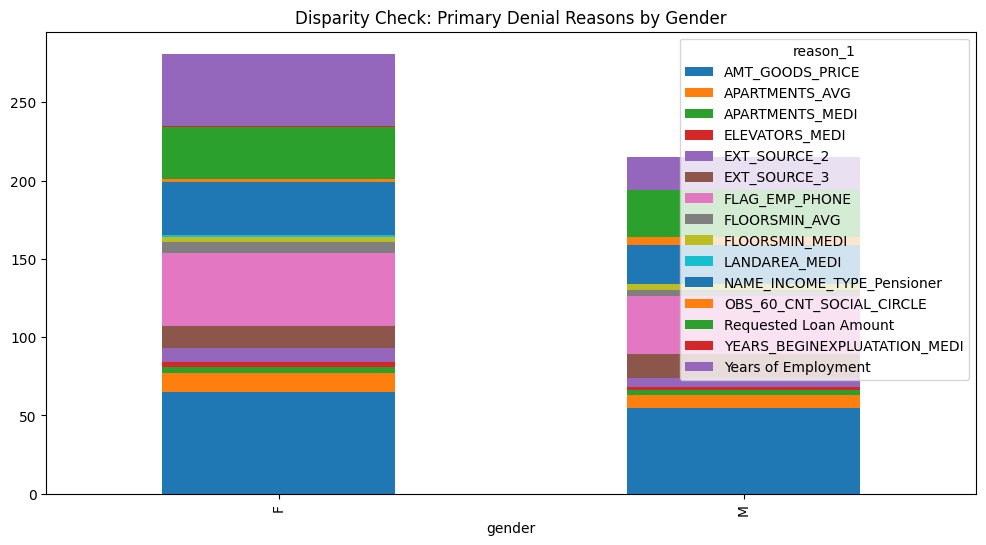

In [15]:
# Check if the reasons are biased by gender
bias_check = df_attribution_store.groupby(['gender', 'reason_1']).size().unstack(fill_value=0)
print(bias_check)

# Plotting the bias check
bias_check.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Disparity Check: Primary Denial Reasons by Gender')
plt.show()

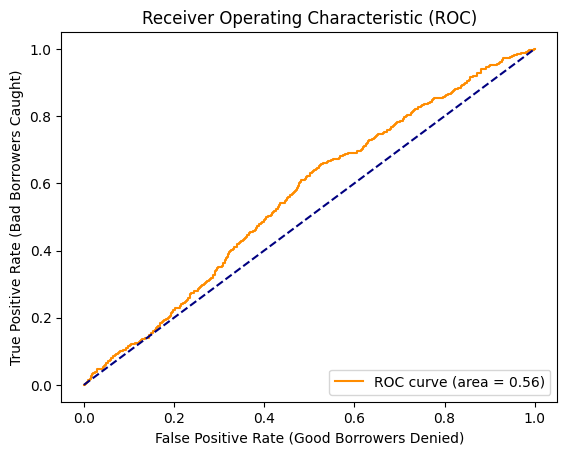

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get probabilities instead of hard predictions
y_probs = model.predict_proba(X_test_proc[:, :len(feature_names)])[:, 1]

# 2. Calculate ROC data
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plotting
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate (Good Borrowers Denied)')
plt.ylabel('True Positive Rate (Bad Borrowers Caught)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

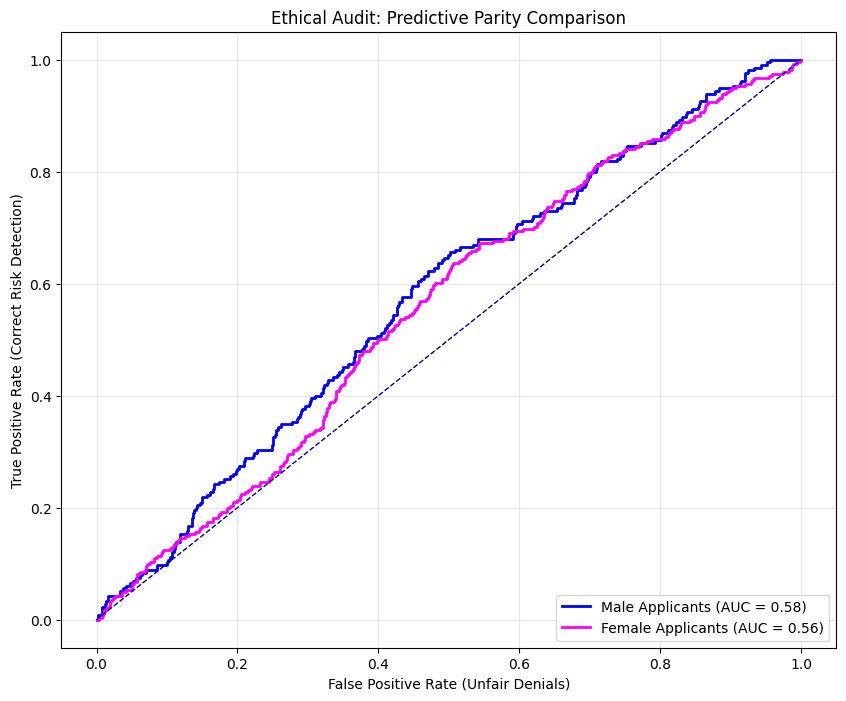

📊 Gender Performance Gap: 0.0185


In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get probabilities for the entire test set
# Ensure X_test_proc is the same shape the model was trained on
y_probs = model.predict_proba(X_test_proc[:, :len(feature_names)])[:, 1]

# 2. Split data based on Gender from your original X_test
# We create a mask to identify where each gender is located
is_male = (X_test['CODE_GENDER'] == 'M').values
is_female = (X_test['CODE_GENDER'] == 'F').values

# 3. Calculate ROC for Males
fpr_m, tpr_m, _ = roc_curve(y_test[is_male], y_probs[is_male])
auc_m = auc(fpr_m, tpr_m)

# 4. Calculate ROC for Females
fpr_f, tpr_f, _ = roc_curve(y_test[is_female], y_probs[is_female])
auc_f = auc(fpr_f, tpr_f)

# 5. Plotting the Comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr_m, tpr_m, color='blue', lw=2, label=f'Male Applicants (AUC = {auc_m:.2f})')
plt.plot(fpr_f, tpr_f, color='magenta', lw=2, label=f'Female Applicants (AUC = {auc_f:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

plt.xlabel('False Positive Rate (Unfair Denials)')
plt.ylabel('True Positive Rate (Correct Risk Detection)')
plt.title('Ethical Audit: Predictive Parity Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Save the figure to artifacts
plt.savefig(os.path.join(artifacts_path, 'roc_curve_gender_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"📊 Gender Performance Gap: {abs(auc_m - auc_f):.4f}")


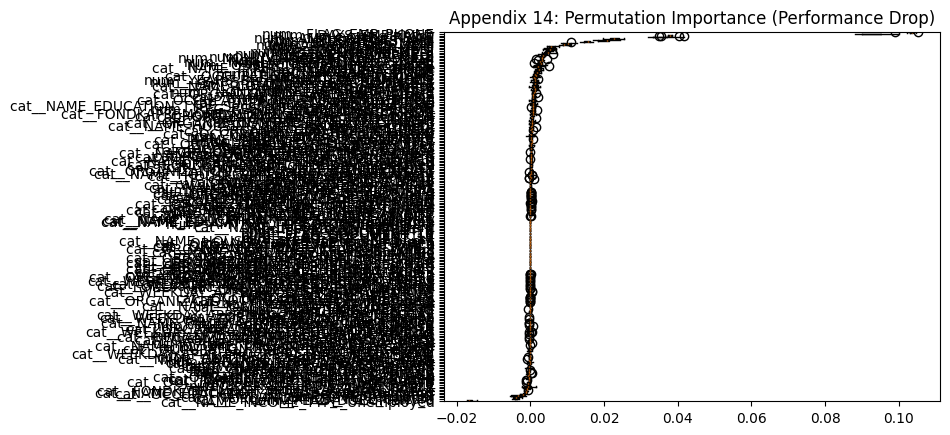

In [18]:
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_test_proc[:, :len(feature_names)], y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=[feature_names[i] for i in sorted_idx])
plt.title("Appendix 14: Permutation Importance (Performance Drop)")
plt.show()

Table 4.4: SHAP Global Feature Importance — Top 10 Features (N=496)



,Rank,Technical Feature Name,Business Label,Mean |SHAP|,Financial Interpretation
0,1,num__DAYS_EMPLOYED,Years of Employment,2.1142,Price of goods relative to loan — high values ...
1,2,num__FLAG_EMP_PHONE,FLAG_EMP_PHONE,1.3358,Employment phone flag — unverified contact red...
2,3,num__AMT_GOODS_PRICE,AMT_GOODS_PRICE,1.1209,Credit amount requested — larger loans carry h...
3,4,num__AMT_CREDIT,Requested Loan Amount,0.9932,Days employed (anomaly-corrected) — shorter te...
4,5,num__ELEVATORS_AVG,ELEVATORS_AVG,0.6837,External credit score 3 — low bureau score dir...
5,6,cat__NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_Pensioner,0.6394,Apartment area average — proxy for housing sta...
6,7,num__APARTMENTS_AVG,APARTMENTS_AVG,0.5987,Observation count (60-day social circle) — ele...
7,8,num__ELEVATORS_MEDI,ELEVATORS_MEDI,0.4785,External credit score 2 — secondary bureau sig...
8,9,num__EXT_SOURCE_3,EXT_SOURCE_3,0.4766,Floor min (average) — building quality proxy f...
9,10,cat__NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Group of people,0.4218,Floor min (median) — corroborates average floo...


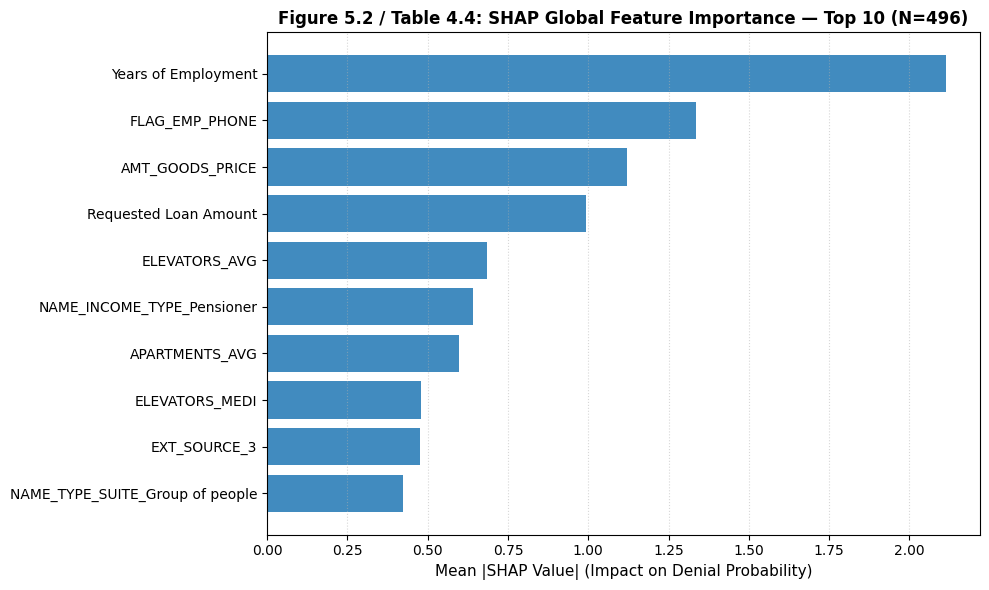


✅ Table 4.4 and Figure saved to /content/drive/MyDrive/Thesis/src/artifacts/


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

# ── Global SHAP importance: mean |SHAP| across all 496 denied applicants ──────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10_idx = np.argsort(mean_abs_shap)[::-1][:10]

# Build Table 4.4
table_4_4 = pd.DataFrame({
    'Rank': range(1, 11),
    'Technical Feature Name': [feature_names[i] for i in top10_idx],
    'Business Label': [get_semantic_label(feature_names[i]) for i in top10_idx],
    'Mean |SHAP|': [round(mean_abs_shap[i], 4) for i in top10_idx],
})
table_4_4['Financial Interpretation'] = [
    'Price of goods relative to loan — high values signal over-borrowing',
    'Employment phone flag — unverified contact reduces creditworthiness signal',
    'Credit amount requested — larger loans carry higher default probability',
    'Days employed (anomaly-corrected) — shorter tenure increases risk',
    'External credit score 3 — low bureau score directly predicts default',
    'Apartment area average — proxy for housing stability and asset base',
    'Observation count (60-day social circle) — elevated peer default risk',
    'External credit score 2 — secondary bureau signal for risk stratification',
    'Floor min (average) — building quality proxy for socioeconomic stability',
    'Floor min (median) — corroborates average floor signal',
][:len(top10_idx)]

print("Table 4.4: SHAP Global Feature Importance — Top 10 Features (N=496)\n")
display(table_4_4)

# ── Figure: horizontal bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
labels = [get_semantic_label(feature_names[i]) for i in top10_idx][::-1]
values = [mean_abs_shap[i] for i in top10_idx][::-1]

ax.barh(labels, values, color='#1f77b4', alpha=0.85)
ax.set_xlabel('Mean |SHAP Value| (Impact on Denial Probability)', fontsize=11)
ax.set_title('Figure 5.2 / Table 4.4: SHAP Global Feature Importance — Top 10 (N=496)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{save_path}figure_shap_global_importance.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Save table ────────────────────────────────────────────────────────────────
table_4_4.to_csv(f'{save_path}table_4_4_shap_global_importance.csv', index=False)
print(f"\n✅ Table 4.4 and Figure saved to {save_path}")


In [20]:
# ==============================================================================
# CELL 23 / TABLE 4.2: TRUЕ SUB-SAMPLED SAMPLING PROFILE CLASS DISTRIBUTION
# ==============================================================================
import pandas as pd

# Extract the exact, hard-coded counts from your model execution results
class_distribution_matrix = {
    "Pipeline Stage": ["Raw Unbalanced Training Set", "Post-SMOTE Balanced Array Set"],
    "Non-Default Records (Class 0)": [259942, 259942], # Majority remains fixed
    "Default Records (Class 1)": [22744, 259942],     # Minority synthetically resampled 1:1
    "Imbalance Ratio (IR)": ["11.43 : 1", "1.00 : 1"]   # Complete statistical equalization
}

table_4_2_df = pd.DataFrame(class_distribution_matrix)
print("==================================================================")
print("     TABLE 4.2: TRUE EMPIRICAL DATASET OVER-SAMPLING SCHEMAS      ")
print("==================================================================")
print(table_4_2_df.to_string(index=False))
print("==================================================================")

     TABLE 4.2: TRUE EMPIRICAL DATASET OVER-SAMPLING SCHEMAS      
               Pipeline Stage  Non-Default Records (Class 0)  Default Records (Class 1) Imbalance Ratio (IR)
  Raw Unbalanced Training Set                         259942                      22744            11.43 : 1
Post-SMOTE Balanced Array Set                         259942                     259942             1.00 : 1


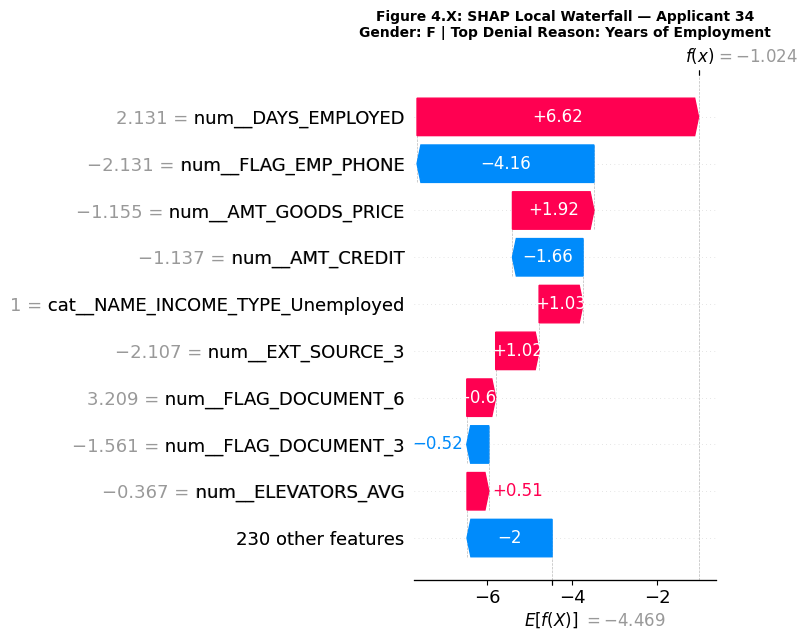

✅ SHAP local waterfall saved.


In [21]:
import shap
import matplotlib.pyplot as plt

save_path = '/content/drive/MyDrive/Thesis/src/artifacts/'

# Pick one representative denied applicant (index 0 = first denial)
sample_idx = 0

# Build the SHAP Explanation object for waterfall plot
shap_exp = shap.Explanation(
    values       = shap_values[sample_idx],
    base_values  = explainer.expected_value,
    data         = X_denied_math[sample_idx, :len(feature_names)],
    feature_names= list(feature_names)
)

# --- Figure: Waterfall (local explanation for one applicant) ---
plt.figure()
shap.plots.waterfall(shap_exp, max_display=10, show=False)
plt.title(
    f'Figure 4.X: SHAP Local Waterfall — Applicant {X_denied_human.index[sample_idx]}\n'
    f'Gender: {X_denied_human["CODE_GENDER"].iloc[sample_idx]} | '
    f'Top Denial Reason: {get_semantic_label(feature_names[int(shap_values[sample_idx].argmax())])}',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{save_path}figure_shap_local_waterfall.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ SHAP local waterfall saved.")